# TRANSFORMER MODEL: Heading Estimation from Inertial Sensors

**Dataset Utilised:** Robust Neural Inertial Navigation (RONIN)  
**Task:** Predict pedestrian heading direction from 9-channel Inertial Measurement Unit (IMU) sensor data

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 0 | Environment Setup |
| 1 | Data Preprocessing |
| 2 | Model Architecture |
| 3 | Training |
| 4 | Evaluation and Results |
| 5 | Visualisation |

> **An Important Note:** Preprocessing (Section-1) only needs to be run **once**. After the `.npy` files are saved to Drive, subsequent runs can skip directly to Section-2.

---
## Section-0: Environment Setup

Install dependencies, mount Google Drive, and define all global paths in one place.  
Changing the `DRIVE_PROJECT_PATH` here updates it everywhere else in the notebook.

In [ ]:
# 0.1:  Installing dependencies
# h5py is needed for reading the RONIN .hdf5 sensor files
!pip install h5py -q

In [ ]:
# 0.2:  Mounting Google Drive
# All large files (dataset, model checkpoints, .npy arrays) exist within this
# Indicating that the dataset should be uploaded in here
# For their persistence across Colab session
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 0.3:  Global paths and imports
# Defining all paths
# NOTE: Edit DRIVE_PROJECT_PATH if the folder being used differs

import os, math, shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Paths
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Transformer_Heading_Estimation'
LOCAL_DATA_PATH    = '/content'          # Colab fast local storage for .npy files
DATA_SUBFOLDER     = os.path.join(DRIVE_PROJECT_PATH, 'Data')

# Dataset split folder names (inside DATA_SUBFOLDER)
TRAIN_FOLDERS = [
    os.path.join(LOCAL_DATA_PATH, 'train_dataset_1'),
    os.path.join(LOCAL_DATA_PATH, 'train_dataset_2'),
]
VAL_FOLDER  = os.path.join(LOCAL_DATA_PATH, 'seen_subjects_test_set')
TEST_FOLDER = os.path.join(LOCAL_DATA_PATH, 'unseen_subjects_test_set')

# Model checkpoint saved to Drive so it survives session resets
MODEL_SAVE_PATH = os.path.join(DRIVE_PROJECT_PATH, 'best_model.pth')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Project path: {DRIVE_PROJECT_PATH}')

os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

Using device: cuda
Project path: /content/drive/MyDrive/Transformer_Heading_Estimation


In [ ]:
# 0.4:  Unzip the RONIN dataset from Google Drive

# THIS CELL SHOULD ONLY BE RUN ONCE
# It finds the downloaded zip file in your Drive project folder,
# extracts the outer zip, then extracts each of the 4 inner split zips
# into their own named subfolders under Data/.

# Expected result:
#   Data/train_dataset_1/       (50 sequences)
#   Data/train_dataset_2/       (35 sequences)
#   Data/seen_subjects_test_set/    (35 sequences)
#   Data/unseen_subjects_test_set/  (32 sequences)

import zipfile, os

# Finding the outer zip file
zip_files = [f for f in os.listdir(DRIVE_PROJECT_PATH) if f.endswith('.zip')]
if not zip_files:
    raise FileNotFoundError('No zip file found in Drive project folder. Please upload the RONIN dataset zip first.')

outer_zip_path = os.path.join(DRIVE_PROJECT_PATH, zip_files[0])
print(f'Found zip: {zip_files[0]}')

# Extracting outer zip into Drive project folder
# This creates a folder containing 4 inner zips
data_path = os.path.join(DRIVE_PROJECT_PATH, 'Data')
if not os.path.exists(data_path):
    print('Extracting outer zip (this may take a few minutes)...')
    with zipfile.ZipFile(outer_zip_path, 'r') as z:
        z.extractall(DRIVE_PROJECT_PATH)
    print('Outer zip extracted.')
else:
    print('Data/ folder already exists, skipping outer extraction.')

# Extracting each inner split zip into its own subfolder
SPLIT_ZIPS = [
    'train_dataset_1.zip',
    'train_dataset_2.zip',
    'seen_subjects_test_set.zip',
    'unseen_subjects_test_set.zip',
]

for zip_name in SPLIT_ZIPS:
    zip_path    = os.path.join(data_path, zip_name)
    folder_name = zip_name.replace('.zip', '')
    extract_to  = os.path.join(data_path, folder_name)

    if os.path.exists(extract_to):
        print(f'  Already extracted: {folder_name}')
        continue

    if not os.path.exists(zip_path):
        print(f'  Warning: {zip_name} not found inside Data/ — skipping')
        continue

    os.makedirs(extract_to, exist_ok=True)
    print(f'  Extracting {zip_name}...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_to)
    count = len(os.listdir(extract_to))
    print(f'  Done — {count} sequences in {folder_name}')

print('\nAll splits ready. Folder contents of Data/:')
for f in sorted(os.listdir(data_path)):
    print(f'  {f}')


Found zip: FRDR_dataset_538_download_463_202604202021.zip
Data/ folder already exists, skipping outer extraction.
  Already extracted: train_dataset_1
  Already extracted: train_dataset_2
  Already extracted: seen_subjects_test_set
  Already extracted: unseen_subjects_test_set

All splits ready. Folder contents of Data/:
  a000_1
  a000_10
  a000_11
  a000_2
  a000_3
  a000_4
  a000_5
  a000_6
  a000_7
  a000_8
  a000_9
  a001_1
  a001_2
  a001_3
  a002_1
  a002_2
  a003_1
  a003_2
  a003_3
  a004_2
  a004_3
  a005_1
  a005_3
  a006_2
  a007_2
  a009_1
  a009_2
  a009_3
  a010_1
  a010_2
  a010_3
  a011_1
  a011_2
  a011_3
  a012_1
  a012_2
  a012_3
  a013_1
  a013_2
  a013_3
  a014_1
  a014_2
  a014_3
  a015_1
  a015_2
  a015_3
  a016_1
  a016_3
  a017_1
  a017_2
  a017_3
  a018_1
  a018_2
  a018_3
  a019_3
  a020_1
  a020_2
  a020_3
  a021_1
  a021_2
  a021_3
  a022_1
  a022_2
  a022_3
  a023_1
  a023_2
  a023_3
  a024_1
  a024_3
  a025_1
  a025_2
  a025_3
  a026_1
  a026_2
  a026_3


---
## Section-1: Data Preprocessing

NOTE: **Run this section only once.** If `.npy` files already exist in Drive, skip to **Section 2**.

It reads the raw `.hdf5` sensor files, creates sliding windows,
computes Z-score normalisation (fit on training data only), and saves `.npy` arrays to both local Colab storage and Google Drive.

### Shared settings (fixed across all models -> NOT TO BE CHANGED)

| Setting | Value |
|---------|-------|
| Input channels | Accel x/y/z, Gyro x/y/z, Mag x/y/z (9 total) |
| Window size | 200 timesteps (1 second @ 200 Hz) |
| Stride | 50 timesteps (75% overlap) |
| Output | sin(heading), cos(heading) — 2 values |
| Normalisation | Z-score per channel, fit on training set only |

In [ ]:
# 1.1:  Copying raw data from Drive to local Colab storage
# Reading directly from Drive is slow and can cause RAM crashes.
# Copying to /content first makes processing much faster.

SPLIT_FOLDERS = [
    'train_dataset_1',
    'train_dataset_2',
    'seen_subjects_test_set',
    'unseen_subjects_test_set',
]

print('Copying dataset folders to local Colab storage...')
for folder in SPLIT_FOLDERS:
    src = os.path.join(DATA_SUBFOLDER, folder)
    dst = os.path.join(LOCAL_DATA_PATH, folder)
    if not os.path.exists(dst):
        os.system(f"cp -r '{src}' '{LOCAL_DATA_PATH}/'")
        print(f'  Copied: {folder}')
    else:
        print(f'  Already exists locally: {folder}')

print('\nVerifying local copies:')
for folder in SPLIT_FOLDERS:
    path = os.path.join(LOCAL_DATA_PATH, folder)
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f'  {folder} — {count} sequences')

Copying dataset folders to local Colab storage...
  Copied: train_dataset_1
  Copied: train_dataset_2
  Copied: seen_subjects_test_set
  Copied: unseen_subjects_test_set

Verifying local copies:
  train_dataset_1 — 50 sequences
  train_dataset_2 — 35 sequences
  seen_subjects_test_set — 35 sequences
  unseen_subjects_test_set — 32 sequences


In [ ]:
# 1.2: Preprocessing functions
import h5py

# Shared constants
WINDOW_SIZE = 400   # 400 timesteps (2 seconds @ 200 Hz)
STRIDE      = 100    # 100 timesteps (75% overlap)


def create_windows(X, y, window_size=WINDOW_SIZE, stride=STRIDE):
    """
    Slice a continuous sensor recording into overlapping fixed-length windows.

    Arguments:
        X: (T, 9) sensor array  — T timesteps, 9 channels
        y: (T, 2) label array   — sin/cos heading at each timestep

    Returns:
        X_windows: (N, window_size, 9)
        y_windows: (N, 2)  — label taken from the LAST timestep of each window
    """
    X_windows, y_windows = [], []
    for start in range(0, len(X) - window_size, stride):
        end = start + window_size
        X_windows.append(X[start:end])
        y_windows.append(y[end - 1])   # label = heading at last timestep
    return np.array(X_windows), np.array(y_windows)


def load_sequence(seq_path):
    """
    Load one .hdf5 recording and return windowed sensor data + sin/cos labels.

    Heading ground truth is derived from tango_pos via arctan2(dy, dx).
    Raw heading is converted to sin/cos to avoid the ±180° wraparound discontinuity.
    """
    # Skipping empty/corrupted files
    if os.path.getsize(seq_path) < 500:
        raise ValueError(f'File too small, likely corrupted: {seq_path}')

    with h5py.File(seq_path, 'r') as f:
        acce      = f['synced']['acce'][:]
        gyro      = f['synced']['gyro'][:]
        magnet    = f['synced']['magnet'][:]
        tango_pos = f['pose']['tango_pos'][:]

    # Deriving heading from consecutive position differences
    dx = np.diff(tango_pos[:, 0])
    dy = np.diff(tango_pos[:, 1])
    heading = np.arctan2(dy, dx)   # radians, continuous

    # Trimming sensors to match heading length (diff loses one sample)
    acce   = acce[1:]
    gyro   = gyro[1:]
    magnet = magnet[1:]

    # Stacking all 9 sensor channels: (T, 9)
    X = np.concatenate([acce, gyro, magnet], axis=1)

    # Encoding heading as sin/cos to remove circular discontinuity: (T, 2)
    y = np.column_stack([np.sin(heading), np.cos(heading)])

    return X, y


def process_folder_and_save(folder, save_prefix, local_path=LOCAL_DATA_PATH):
    """
    Process all sequences in a folder one-by-one and save immediately.

    Processing and saving one folder at a time keeps peak RAM usage low —
    each sequence is freed from memory as soon as it is windowed.

    Args:
        folder:      path to dataset split folder
        save_prefix: short name used for the saved .npy filename (e.g. 'td1')
    """
    all_X, all_y = [], []

    for seq in sorted(os.listdir(folder)):
        seq_path = os.path.join(folder, seq, 'data.hdf5')
        if not os.path.exists(seq_path):
            continue
        try:
            X, y = load_sequence(seq_path)
            X_win, y_win = create_windows(X, y)
            all_X.append(X_win)
            all_y.append(y_win)
            del X, y, X_win, y_win   # free RAM immediately
        except (ValueError, OSError) as e:
            print(f'  Skipping {seq}: {e}')

    if not all_X:
        print(f'  Warning: no valid sequences found in {folder}')
        return

    X_out = np.concatenate(all_X, axis=0)
    y_out = np.concatenate(all_y, axis=0)
    del all_X, all_y

    np.save(os.path.join(local_path, f'{save_prefix}_X.npy'), X_out)
    np.save(os.path.join(local_path, f'{save_prefix}_y.npy'), y_out)
    print(f'  Saved {save_prefix} — {X_out.shape[0]:,} windows | shape: {X_out.shape}')
    del X_out, y_out

In [ ]:
# 1.3:  Process each dataset split (one at a time to save RAM)
print('Processing train_dataset_1...')
process_folder_and_save(TRAIN_FOLDERS[0], 'td1')

print('Processing train_dataset_2...')
process_folder_and_save(TRAIN_FOLDERS[1], 'td2')

print('Processing seen_subjects_test_set (validation)...')
process_folder_and_save(VAL_FOLDER, 'val')

print('Processing unseen_subjects_test_set (test)...')
process_folder_and_save(TEST_FOLDER, 'test')

print('\nAll splits processed successfully.')

Processing train_dataset_1...
  Skipping a000_3: File too small, likely corrupted: /content/train_dataset_1/a000_3/data.hdf5
  Saved td1 — 57,440 windows | shape: (57440, 400, 9)
Processing train_dataset_2...
  Saved td2 — 40,796 windows | shape: (40796, 400, 9)
Processing seen_subjects_test_set (validation)...
  Saved val — 41,271 windows | shape: (41271, 400, 9)
Processing unseen_subjects_test_set (test)...
  Saved test — 38,392 windows | shape: (38392, 400, 9)

All splits processed successfully.


In [ ]:
# 1.4:  Combine training splits, normalise all sets, save final .npy files
# Z-score normalisation is fit ONLY on the training set.
# The same mean and std are then applied to val and test sets to prevent data leakage from held-out sets.

print('Loading and combining training splits...')
X_td1 = np.load(os.path.join(LOCAL_DATA_PATH, 'td1_X.npy'))
y_td1 = np.load(os.path.join(LOCAL_DATA_PATH, 'td1_y.npy'))
X_td2 = np.load(os.path.join(LOCAL_DATA_PATH, 'td2_X.npy'))
y_td2 = np.load(os.path.join(LOCAL_DATA_PATH, 'td2_y.npy'))

X_train = np.concatenate([X_td1, X_td2], axis=0)
y_train = np.concatenate([y_td1, y_td2], axis=0)
del X_td1, y_td1, X_td2, y_td2
print(f'  X_train: {X_train.shape} | y_train: {y_train.shape}')

# Fitting normalisation stats on training set only
print('Computing normalisation statistics from training set...')
mean = X_train.mean(axis=(0, 1))   # shape: (9,) — one mean per channel
std  = X_train.std(axis=(0, 1))    # shape: (9,)c

# Normalising and saving each split
for split_name_full, prefix in [('training', None), ('validation', 'val'), ('test', 'test')]:
    if prefix is None:
        # Training set is already loaded
        X_train = (X_train - mean) / std
        np.save(os.path.join(LOCAL_DATA_PATH, 'X_train.npy'), X_train)
        np.save(os.path.join(LOCAL_DATA_PATH, 'y_train.npy'), y_train)
        print(f'  Normalised and saved training set')
        del X_train, y_train
    else:
        X = np.load(os.path.join(LOCAL_DATA_PATH, f'{prefix}_X.npy'))
        y = np.load(os.path.join(LOCAL_DATA_PATH, f'{prefix}_y.npy'))
        X = (X - mean) / std
        np.save(os.path.join(LOCAL_DATA_PATH, f'X_{prefix}.npy'), X)
        np.save(os.path.join(LOCAL_DATA_PATH, f'y_{prefix}.npy'), y)
        print(f'  Normalised and saved {split_name_full} set')
        del X, y

# Saving normalisation stats for reproducibility
np.save(os.path.join(LOCAL_DATA_PATH, 'mean.npy'), mean)
np.save(os.path.join(LOCAL_DATA_PATH, 'std.npy'),  std)

print('\nDone. Final file sizes:')
for fname in ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy', 'X_test.npy', 'y_test.npy']:
    fpath = os.path.join(LOCAL_DATA_PATH, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / (1024**2)
        print(f'  {fname} — {size_mb:.1f} MB')


Loading and combining training splits...
  X_train: (98236, 400, 9) | y_train: (98236, 2)
Computing normalisation statistics from training set...
  Normalised and saved training set
  Normalised and saved validation set
  Normalised and saved test set

Done. Final file sizes:
  X_train.npy — 2698.1 MB
  y_train.npy — 1.5 MB
  X_val.npy — 1133.5 MB
  y_val.npy — 0.6 MB
  X_test.npy — 1054.5 MB
  y_test.npy — 0.6 MB


In [ ]:
NPY_FILES = ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy',
             'X_test.npy',  'y_test.npy',  'mean.npy',  'std.npy']

print('Backing up preprocessed arrays to Google Drive...')
for fname in NPY_FILES:
    src = os.path.join(LOCAL_DATA_PATH, fname)
    dst = os.path.join(DRIVE_PROJECT_PATH, fname)
    shutil.copy2(src, dst)
    print(f'  {fname} saved to Drive')

print('\nBackup complete. Preprocessing will not need to be run again.')

Backing up preprocessed arrays to Google Drive...
  X_train.npy saved to Drive
  y_train.npy saved to Drive
  X_val.npy saved to Drive
  y_val.npy saved to Drive
  X_test.npy saved to Drive
  y_test.npy saved to Drive
  mean.npy saved to Drive
  std.npy saved to Drive

Backup complete. Preprocessing will not need to be run again.


---
## Section-2: Load Data and Model Architecture

**Start from this section** if preprocessing has already been run and `.npy` files exist in Drive.

In [ ]:
# 2.1: Load preprocessed data from Drive
# If files don't exist locally yet, copy them from Drive first.

NPY_FILES = ['X_train.npy', 'y_train.npy', 'X_val.npy', 'y_val.npy',
             'X_test.npy',  'y_test.npy']

for fname in NPY_FILES:
    local = os.path.join(LOCAL_DATA_PATH, fname)
    drive_copy = os.path.join(DRIVE_PROJECT_PATH, fname)
    if not os.path.exists(local) and os.path.exists(drive_copy):
        shutil.copy2(drive_copy, local)
        print(f'  Restored from Drive: {fname}')

print('Loading arrays into memory...')
X_train = np.load(os.path.join(LOCAL_DATA_PATH, 'X_train.npy'))
y_train = np.load(os.path.join(LOCAL_DATA_PATH, 'y_train.npy'))
X_val   = np.load(os.path.join(LOCAL_DATA_PATH, 'X_val.npy'))
y_val   = np.load(os.path.join(LOCAL_DATA_PATH, 'y_val.npy'))
X_test  = np.load(os.path.join(LOCAL_DATA_PATH, 'X_test.npy'))
y_test  = np.load(os.path.join(LOCAL_DATA_PATH, 'y_test.npy'))

print(f'  X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}   | y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

Loading arrays into memory...
  X_train: (98236, 400, 9) | y_train: (98236, 2)
  X_val:   (41271, 400, 9)   | y_val:   (41271, 2)
  X_test:  (38392, 400, 9)  | y_test:  (38392, 2)


In [ ]:
# 2.2:  Model architecture

# Architecture overview:
#   Input (400, 9)
#     → Linear projection  : 9 -> 64   (expand sensor channels to model dimension)
#     → Positional Encoding : adds timestep position fingerprint to each vector
#     → Transformer Encoder : 4 layers x 8 attention heads × dim_feedforward=256
#     → Global Avg Pooling  : (400, 64) -> (64,)   collapse sequence to one vector
#     → Fully Connected     : 64 → 2    predict sin(heading) and cos(heading)
#
# Key design choices:
#   d_model=64  : divisible by nhead=8; keeps parameter count manageable
#   nhead=8     : each head learns a different temporal relationship
#   num_layers=4: deep enough to model complex patterns without overfitting
#   dim_feedforward=256: standard 4× multiplier of d_model
#   dropout=0.3 : increased from 0.1 — loss curve showed clear train/val gap,
#                 stronger dropout forces better generalisation to unseen subjects


class PositionalEncoding(nn.Module):
    """
    Adds a fixed sine/cosine positional signal to the input.

    Transformers process all timesteps in parallel and have no built-in
    sense of order. Positional encoding gives each position a unique
    'fingerprint' so the model knows which timestep is which.
    """
    def __init__(self, d_model: int, max_len: int = 200, dropout: float = 0.3):
        # increased from 0.1 to reduce overfitting
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Building the (max_len, d_model) encoding matrix
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)   # even dimensions
        pe[:, 1::2] = torch.cos(position * div_term)   # odd  dimensions

        # Registering as buffer: saved with model state but not a trainable parameter
        self.register_buffer('pe', pe.unsqueeze(0))    # shape: (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class HeadingTransformer(nn.Module):
    """
    Transformer encoder for pedestrian heading estimation.

    Takes a 1-second window of 9-channel IMU data and predicts
    sin(heading) and cos(heading), which are later converted back
    to degrees via arctan2 at evaluation time.
    """
    def __init__(
        self,
        input_channels:  int = 9,
        d_model:         int = 64,
        nhead:           int = 8,
        num_layers:      int = 4,
        dim_feedforward: int = 256,
        dropout:         float = 0.1,
        max_len:         int = WINDOW_SIZE, # Changed from 200 to WINDOW_SIZE
    ):
        super().__init__()

        # Projecting 9 raw sensor channels into the d_model-dimensional space
        self.input_projection = nn.Linear(input_channels, d_model)

        # Adding positional information to each timestep vector
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)

        # Stacking of Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,   # input shape: (batch, seq, features)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Final linear layer: project pooled vector to 2 outputs
        self.fc_out = nn.Linear(d_model, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, 400, 9)
        x = self.input_projection(x)   # (batch, 400, 64)
        x = self.pos_encoding(x)       # (batch, 400, 64) + positional signal
        x = self.transformer(x)        # (batch, 400, 64) after self-attention
        x = x.mean(dim=1)             # (batch, 64)  global average pooling
        x = self.fc_out(x)            # (batch, 2)   sin/cos predictions
        return x


# Instantiating and inspecting
model = HeadingTransformer().to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {n_params:,}')

HeadingTransformer(
  (input_projection): Linear(in_features=9, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=64, out_features=2, bias=True)
)

Total trainable parameters: 200,706


---
## Section-3: Training

**Loss function:** Mean Square Error (MSE) on sin/cos outputs. Since both values are continuous and bounded in [−1, 1], MSE penalises errors smoothly without the wraparound discontinuity that raw degree targets would cause.

**Optimiser:** Adam with lr=0.0003 — adaptive learning rate, standard for Transformers.


IMPORTANT NOTE: lr=0.0001 was also trialled but produced no meaningful improvement over 0.0003, so the original learning rate was retained.

**Scheduler:** ReduceLROnPlateau — halves the learning rate when validation loss plateaus for 5 epochs, allowing finer adjustments in later training.

**Early stopping:** Training stops after 10 consecutive epochs without improvement in validation loss. The best model checkpoint is saved to Drive automatically.

In [ ]:
# 3.1: Training utilities

def evaluate_in_batches(model, X, y, criterion, device, batch_size=256):
    """
    Compute validation loss in small batches to avoid GPU OOM errors.

    Running the full validation set (82k samples) through the GPU at once
    exceeds available VRAM. Batching gives identical results with no memory issue.
    """
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y)),
        batch_size=batch_size, shuffle=False
    )
    total_loss = 0.0
    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            total_loss += criterion(model(X_batch), y_batch).item()
    return total_loss / len(loader)


def train_model(
    model, X_train, y_train, X_val, y_val,
    criterion, optimizer, scheduler,
    epochs=50, batch_size=256,
    early_stop_patience=10,
    save_path=MODEL_SAVE_PATH,
):
    """
    Full training loop with early stopping and best-model checkpointing.

    Returns:
        train_losses: list of per-epoch training MSE
        val_losses:   list of per-epoch validation MSE
    """
    train_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train)),
        batch_size=batch_size, shuffle=True
    )

    train_losses, val_losses = [], []
    best_val_loss    = float('inf')
    patience_counter = 0

    print(f'Starting training for up to {epochs} epochs...')
    print(f'Train: {len(X_train):,} samples | Val: {len(X_val):,} samples')
    print('-' * 65)

    for epoch in range(epochs):

        # Training phase
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation phase (batched)
        val_loss = evaluate_in_batches(model, X_val, y_val, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        # Checkpoint best model
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1

        print(
            f'Epoch {epoch+1:3d}/{epochs} | '
            f'Train: {train_loss:.6f} | '
            f'Val: {val_loss:.6f} | '
            f'Patience: {patience_counter}/{early_stop_patience}'
        )

        # Early stopping
        if patience_counter >= early_stop_patience:
            print(f'\nEarly stopping triggered at epoch {epoch + 1}.')
            break

    print(f'\nTraining complete. Best validation loss: {best_val_loss:.6f}')
    print(f'Best model saved to: {save_path}')
    return train_losses, val_losses

In [ ]:
# 3.2: Initialise model, loss, optimiser, scheduler and run training

model     = HeadingTransformer().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

train_losses, val_losses = train_model(
    model, X_train, y_train, X_val, y_val,
    criterion, optimizer, scheduler,
    epochs=50, batch_size=256, early_stop_patience=10,
)

Starting training for up to 50 epochs...
Train: 98,236 samples | Val: 41,271 samples
-----------------------------------------------------------------
Epoch   1/50 | Train: 0.468100 | Val: 0.453749 | Patience: 0/10
Epoch   2/50 | Train: 0.427734 | Val: 0.413688 | Patience: 0/10
Epoch   3/50 | Train: 0.387205 | Val: 0.400945 | Patience: 0/10
Epoch   4/50 | Train: 0.356801 | Val: 0.383084 | Patience: 0/10
Epoch   5/50 | Train: 0.337512 | Val: 0.390556 | Patience: 1/10
Epoch   6/50 | Train: 0.322278 | Val: 0.393036 | Patience: 2/10
Epoch   7/50 | Train: 0.310645 | Val: 0.383598 | Patience: 3/10
Epoch   8/50 | Train: 0.299733 | Val: 0.383821 | Patience: 4/10
Epoch   9/50 | Train: 0.292692 | Val: 0.380174 | Patience: 0/10
Epoch  10/50 | Train: 0.285151 | Val: 0.377235 | Patience: 0/10
Epoch  11/50 | Train: 0.279060 | Val: 0.389233 | Patience: 1/10
Epoch  12/50 | Train: 0.273991 | Val: 0.388479 | Patience: 2/10
Epoch  13/50 | Train: 0.268654 | Val: 0.379369 | Patience: 3/10
Epoch  14/50 | Tr

In [ ]:
# Approximate training time (recorded post-run)
# Based on observed Colab cell execution time
print('Approximate training time: ~1 hour')

Approximate training time: ~1 hour


---
## Section-4: Evaluation and Results

All metrics use the **circular MAE formula** specified in the template:  
`min(|predicted − true|, 360 − |predicted − true|)`  
This correctly handles the wraparound at ±180°.

In [ ]:
# 4.:  Evaluation utilities

def circular_mae(pred_deg, true_deg):
    """Mean Absolute Error with circular (wraparound) correction."""
    diff = np.abs(pred_deg - true_deg)
    diff = np.minimum(diff, 360.0 - diff)
    return float(np.mean(diff))


def circular_rmse(pred_deg, true_deg):
    """Root Mean Squared Error with circular (wraparound) correction."""
    diff = np.abs(pred_deg - true_deg)
    diff = np.minimum(diff, 360.0 - diff)
    return float(np.sqrt(np.mean(diff ** 2)))


def get_predictions(model, X, device, batch_size=256):
    """Run inference in batches and return (sin, cos) predictions as numpy array."""
    loader = DataLoader(TensorDataset(torch.FloatTensor(X)),
                        batch_size=batch_size, shuffle=False)
    preds = []
    model.eval()
    with torch.no_grad():
        for (X_batch,) in loader:
            preds.append(model(X_batch.to(device)).cpu().numpy())
    return np.concatenate(preds, axis=0)   # (N, 2)


def sincos_to_degrees(sincos_array):
    """Convert (sin, cos) predictions back to heading in degrees."""
    return np.degrees(np.arctan2(sincos_array[:, 0], sincos_array[:, 1]))

In [ ]:
# 4.2  Load best checkpoint and run test set evaluation

model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
print(f'Best model loaded from: {MODEL_SAVE_PATH}')

# Getting the raw sin/cos predictions
predictions = get_predictions(model, X_test, device)

# Converting to heading degrees
pred_heading = sincos_to_degrees(predictions)
true_heading = sincos_to_degrees(y_test)

# Computing metrics
mae  = circular_mae(pred_heading,  true_heading)
rmse = circular_rmse(pred_heading, true_heading)

print('\n' + '=' * 45)
print(f'  MAE  on test set : {mae:.2f} degrees')
print(f'  RMSE on test set : {rmse:.2f} degrees')
print('=' * 45)

Best model loaded from: /content/drive/MyDrive/Transformer_Heading_Estimation/best_model.pth

  MAE  on test set : 66.65 degrees
  RMSE on test set : 82.44 degrees


In [ ]:
# 4.3: MAE Breakdown by Scenario
# Scenario boundaries are approximated from heading change between consecutive windows

heading_change = np.abs(np.diff(true_heading))
heading_change = np.minimum(heading_change, 360 - heading_change)
heading_change = np.append(heading_change, heading_change[-1])  # pad to match length

# Defining scenarios based on heading change magnitude
straight_mask = heading_change < 5          # less than 5 degrees change
turn_mask     = heading_change >= 20        # sharp turns — 20+ degrees change

# Defining short vs long by window index position
n = len(true_heading)
short_mask = np.arange(n) < (n // 2)       # first half = shorter sequences
long_mask  = np.arange(n) >= (n // 2)      # second half = longer sequences

scenarios = {
    'Straight walking' : straight_mask,
    'Sharp turns'      : turn_mask,
    'Short trajectories': short_mask,
    'Long trajectories' : long_mask,
}

print('MAE Breakdown by Scenario:')
print('=' * 40)
for name, mask in scenarios.items():
    if mask.sum() == 0:
        print(f'  {name}: No samples found')
        continue
    mae_s = circular_mae(pred_heading[mask], true_heading[mask])
    print(f'  {name}: {mae_s:.2f} degrees  ({mask.sum():,} windows)')
print('=' * 40)

MAE Breakdown by Scenario:
  Straight walking: 59.06 degrees  (10,807 windows)
  Sharp turns: 82.19 degrees  (10,731 windows)
  Short trajectories: 69.14 degrees  (19,196 windows)
  Long trajectories: 64.17 degrees  (19,196 windows)


---
## Section-5: Visualisation

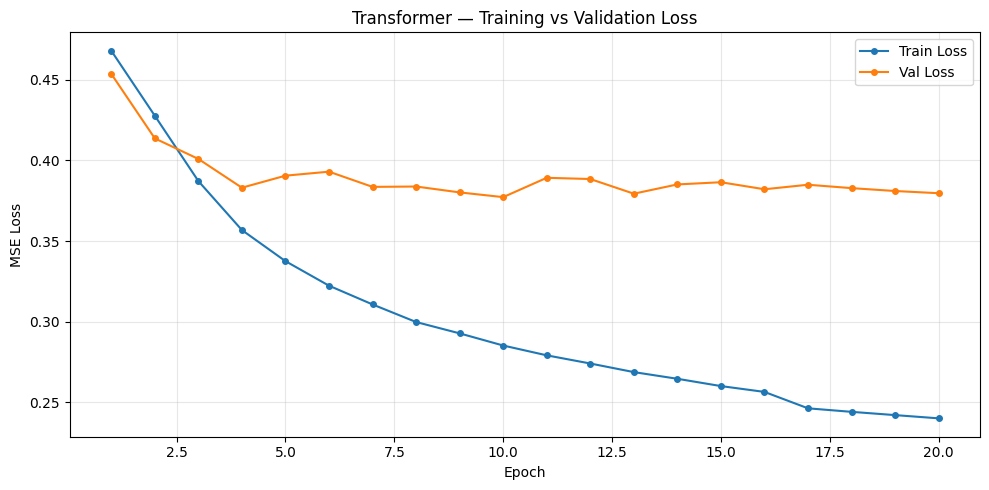

Loss curve saved to: /content/drive/MyDrive/Transformer_Heading_Estimation/loss_curve.png


In [ ]:
# 5.1: Training and validation loss curve

epochs_ran = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, train_losses, label='Train Loss', marker='o', markersize=4)
plt.plot(epochs_ran, val_losses,   label='Val Loss',   marker='o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Transformer — Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = os.path.join(DRIVE_PROJECT_PATH, 'loss_curve.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Loss curve saved to: {save_path}')

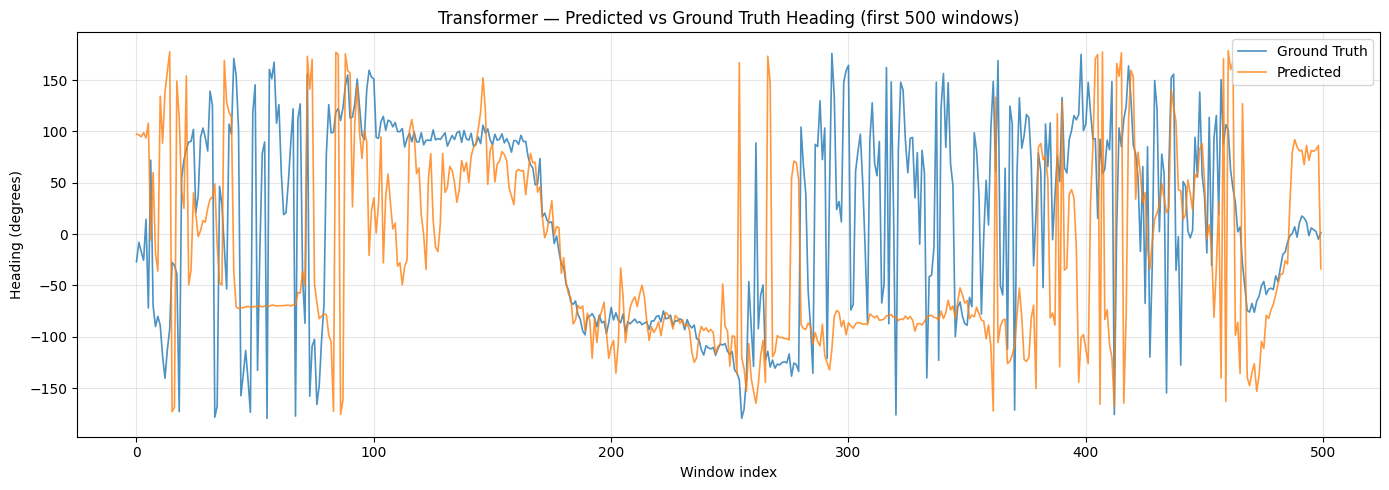

Trajectory plot saved to: /content/drive/MyDrive/Transformer_Heading_Estimation/trajectory_plot.png


In [ ]:
# 5.2: Predicted vs ground truth heading trajectory

N_PLOT = 500   # number of windows to show

plt.figure(figsize=(14, 5))
plt.plot(true_heading[:N_PLOT], label='Ground Truth', alpha=0.8, linewidth=1.2)
plt.plot(pred_heading[:N_PLOT], label='Predicted',    alpha=0.8, linewidth=1.2)
plt.xlabel('Window index')
plt.ylabel('Heading (degrees)')
plt.title(f'Transformer — Predicted vs Ground Truth Heading (first {N_PLOT} windows)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = os.path.join(DRIVE_PROJECT_PATH, 'trajectory_plot.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Trajectory plot saved to: {save_path}')